# 15회차 — 기상 변수 탐색

전 생애 더위 노출(THI 비율)이 한우 등급·가격과
어떻게 연관되는지 그림으로 확인한다.
인과 증명 단계가 아닌, 패턴이 보이는지 그림과 간단한 검정으로 보는 단계

In [1]:
from statistics import mean

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.ma.core import std
from scipy.stats import mannwhitneyu, kruskal
import platform, os
import warnings
warnings.filterwarnings("ignore") #실행중 나오는 경고메시지 숨김

#한글 폰트, 그래프 스타일 설정,저장폴더 생성
def set_korean_font():
    system = platform.system()
    if system == "Darwin":
        plt.rcParams["font.family"] = "AppleGothic"
    elif system == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "NanumGothic"
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
sns.set_style("whitegrid") #그래프 배경 흰색 격자 스타일
os.makedirs("../figures", exist_ok=True) #그래프 저장폴더가 없으면 만듦, 있으면 넘어감

In [3]:
#셀3 로드+등급+더위 비율 생성
df = pd.read_csv("../../../data/processed/2_preprocess/step6_preprocess_eng.csv",
                 encoding="utf-8-sig", low_memory=False)
for c in ["ABATT_DATE","BIRTH_YMD","JUDGE_DATE"]:
    df[c] = pd.to_datetime(df[c], errors="coerce") #날짜 컬럼 -> 날짜타입으로 변환

#등급 -> 숫자로 변환
if "grade_num" not in df.columns:
    grade_map = {"1++A":15,"1++B":14,"1++C":13,"1+A":12,"1+B":11,"1+C":10,
                 "1A":9,"1B":8,"1C":7,"2A":6,"2B":5,"2C":4,"3A":3,"3B":2,"3C":1,"등외":0}
    df["grade_num"] = df["LAST_GRADE"].map(grade_map)

#그래프에서 등급순서 고정
grade_order = ["1++A","1++B","1++C","1+A","1+B","1+C",
               "1A","1B","1C","2A","2B","2C","3A","3B","3C","등외"]
grade_order = [g for g in grade_order if g in df["LAST_GRADE"].unique()]

# 더위 노출 비율 (전 생애)
df["ratio_고온"]   = (df["days_caution"]+df["days_warning"]+df["days_danger"]) / df["days_total"]
df["ratio_강더위"] = (df["days_warning"]+df["days_danger"]) / df["days_total"]
df["ratio_위험"]   = df["days_danger"] / df["days_total"]

print(f"데이터: {df.shape}")
print(df[["ratio_고온","ratio_강더위","ratio_위험"]].describe().round(3))

# 열 48개인 이유 : grade_num, ratio_고온, ratio_강더위, ratio_위험 4개 추가
# count : 결측 아닌 데이터 개수
# mean : 평균(총 비율, 평균) (ex:0.415 = 전체소들 평균적 생애 41.5%를 THI72 잇상 고온상태에서 보냄)
# std : 표준편차(값들이 평균에서 얼마나 퍼졌는가)
# min : 최솟값
# 25% : 하위25%,1사분위수 (전체 소중 25%는 ratio_고온이 0.382 이하이다)?
# 50% : 중앙값
# 75% : 3사분위수
# max : 최댓값


데이터: (2408699, 48)
          ratio_고온    ratio_강더위     ratio_위험
count  2408699.000  2408699.000  2408699.000
mean         0.415        0.274        0.032
std          0.050        0.048        0.023
min          0.000        0.000        0.000
25%          0.382        0.242        0.015
50%          0.414        0.274        0.028
75%          0.449        0.306        0.046
max          1.000        1.000        0.333


## 1. 등급별 고온노출 비율

좋은 등급(1++)이 낮고 나쁜 등급(3C·등외)이 높으면 더위 영향 가설 지지.

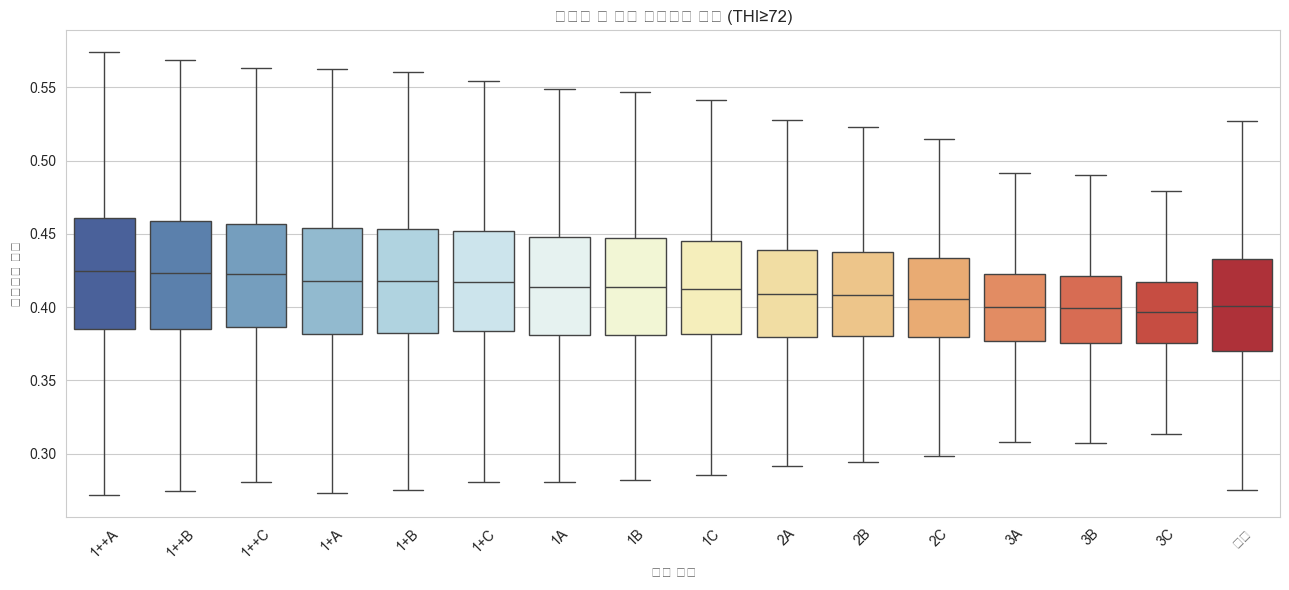

등급별 평균 고온노출 비율:
LAST_GRADE
1++A    0.422
1++B    0.421
1++C    0.421
1+A     0.417
1+B     0.417
1+C     0.417
1A      0.414
1B      0.414
1C      0.413
2A      0.409
2B      0.409
2C      0.406
3A      0.399
3B      0.397
3C      0.395
등외      0.401
Name: ratio_고온, dtype: float64


In [5]:
# 각 등급 소들이 평균적으로 생애 기간중 얼마나 고온에 노출됐는지 42.1% 이런식(고온= THI>=72)
plt.figure(figsize=(13, 6))
sns.boxplot(data=df, x="LAST_GRADE", y="ratio_고온", order=grade_order,
            hue="LAST_GRADE", hue_order=grade_order, palette="RdYlBu_r",
            legend=False, showfliers=False)
plt.title("등급별 전 생애 고온노출 비율 (THI≥72)")
plt.xlabel("최종 등급"); plt.ylabel("고온노출 비율")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../../figures/weather-variables/15_ratio_by_grade.png", dpi=100, bbox_inches="tight")
plt.show()

print("등급별 평균 고온노출 비율:")
print(df.groupby("LAST_GRADE")["ratio_고온"].mean().reindex(grade_order).round(3))

## 2. 고온노출 vs 가격 (수익성)

COST_AMT는 결측 37%라 가격 있는 행만 그려짐.

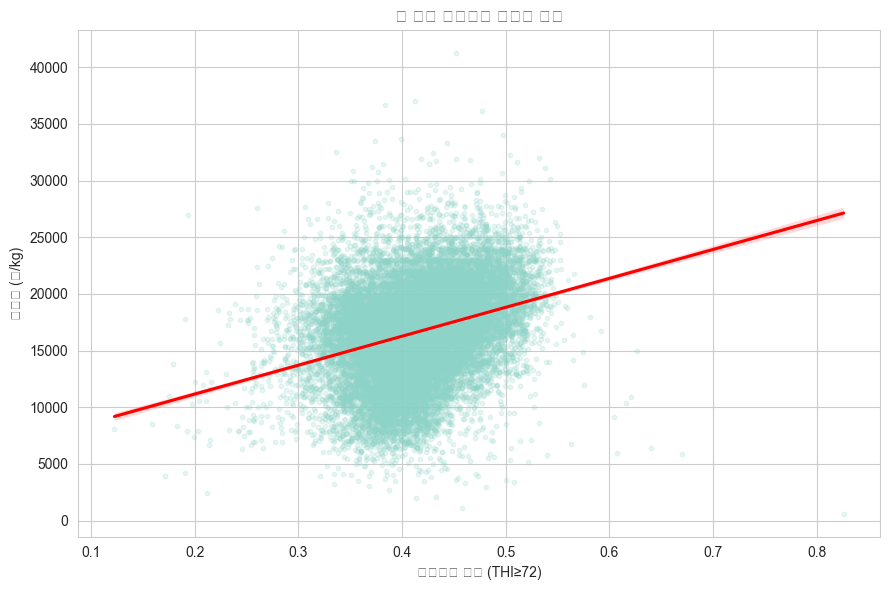

고온노출 비율 × 가격 상관: r = +0.300


In [6]:
#셀7 고온노출 비율과 가격의 관계 -> 산점도+추세선
df_price = df[df["COST_AMT"].notnull()] # 가격이 있는 행만 사용(결측 제외)

#그래프 너무 무거워서 최대 20000개만 샘플링해서 그림(random_state=42 : 같은 샘플이 뽑히게 고정
df_sample = df_price.sample(n=min(20000, len(df_price)), random_state=42)
plt.figure(figsize=(9, 6))

#산점도,회귀 추세선 같이 그림
sns.regplot(data=df_sample, x="ratio_고온", y="COST_AMT",
            scatter_kws={"alpha":0.2,"s":10}, line_kws={"color":"red"})
plt.title("전 생애 고온노출 비율과 가격")
plt.xlabel("고온노출 비율 (THI≥72)"); plt.ylabel("낙찰가 (원/kg)")
plt.tight_layout()

#그래프를 이미지로 저장
plt.savefig("../../../figures/weather-variables/15_ratio_vs_cost(고온노출vs가격).png", dpi=100, bbox_inches="tight")
plt.show()
r = df_price[["ratio_고온","COST_AMT"]].corr().iloc[0, 1]
print(f"고온노출 비율 × 가격 상관: r = {r:+.3f}")

# r = +0.3  -> 고온노출 비율과 가격 사이 약한 양의 상관 있음(고온노출 비율 상승시 COST_AMT도 높아지는 경향)
# 산점도에서 우상향 추세, 더위가 가격을 높이는 의미가 아니라, 등급,지역,출하 시기,농장 특성 등 다른 요인이 함께 반영된 결과일 가능성이 높음

## 3. 출생 계절별 등급 (장기 영향)

여름에 태어난 송아지가 평생 등급이 낮은지.

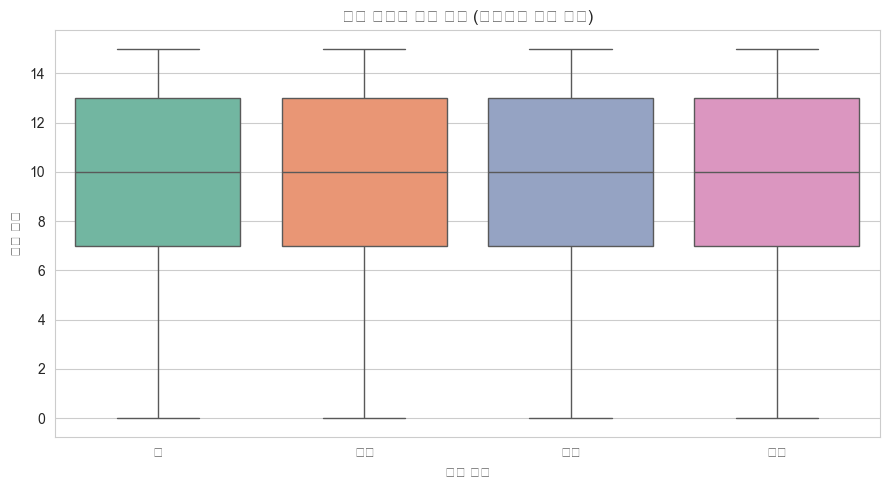

출생 계절별 등급 Kruskal-Wallis: H=610.4, p=5.686e-132


In [7]:
# 셀9
month_to_season = {12:"겨울",1:"겨울",2:"겨울", 3:"봄",4:"봄",5:"봄",
                   6:"여름",7:"여름",8:"여름", 9:"가을",10:"가을",11:"가을"}
df["birth_season"] = df["BIRTH_YMD"].dt.month.map(month_to_season) #생년월일에서 월을 뽑음
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="birth_season", y="grade_num", order=["봄","여름","가을","겨울"],
            hue="birth_season", hue_order=["봄","여름","가을","겨울"],
            palette="Set2", legend=False, showfliers=False)
plt.title("출생 계절별 등급 점수 (높을수록 좋은 등급)")
plt.xlabel("출생 계절"); plt.ylabel("등급 점수")
plt.tight_layout()
plt.savefig("../../../figures/weather-variables/15_birth_season(출생 계절별 등급).png", dpi=100, bbox_inches="tight")
plt.show()

groups = [df[df["birth_season"]==s]["grade_num"].dropna()
          for s in ["봄","여름","가을","겨울"]]
h, p = kruskal(*groups)
print(f"출생 계절별 등급 Kruskal-Wallis: H={h:.1f}, p={p:.4g}")

# Kruskal-Wallis검정 : 3개이상 그룹의 분포가 서로 다른지 확인하는 비모수검정
# p < 0.05 -> 출생 계절별 등급차이가 통계적으로 유의함
# 출생 계절에 따른 등급 차이는 통계적으로 유의하지만, box-plot상 분포 차이는 매우 작아 실질적 영향 크지않음
# H 큼, p 매우 작음 → 통계적으로 차이는 있음
# 박스플롯 거의 같음 → 실제 차이는 작아 보임

## 4. 고온노출 구간별 평균 등급 (핵심)

더위 노출을 4구간으로 나눠 평균 등급이 떨어지는 추세가 있는지 본다.
※ qcut에 duplicates="drop" — 더위 0인 소가 많아 구간 경계가 겹쳐도 안전.

           mean_grade       n  std_grade
고온_bin                                  
낮음(하위25%)       9.313  602180      3.865
중하              8.889  602186      3.935
중상              9.542  602162      3.773
높음(상위25%)      10.568  602171      3.367


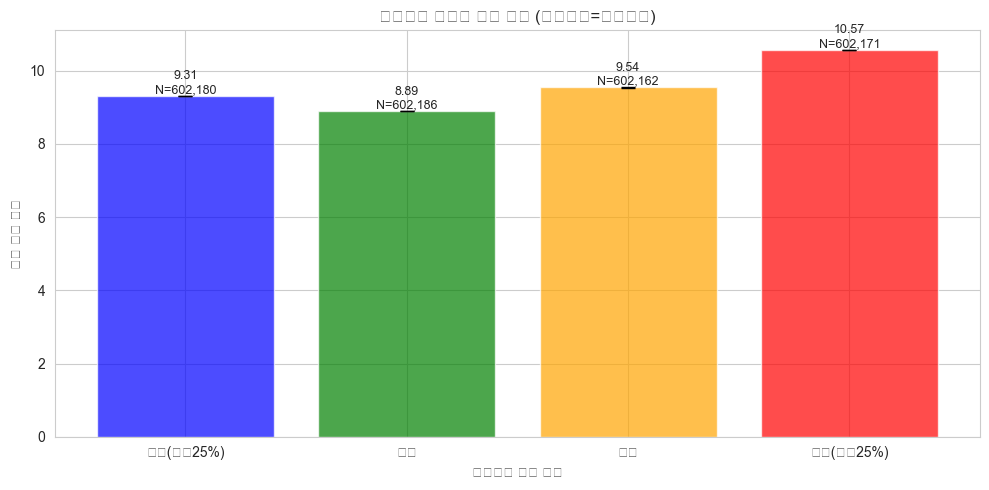

In [9]:
# 비율을 4구간으로 (duplicates="drop"으로 경계 중복 방어) 셀11
df["고온_bin"] = pd.qcut(df["ratio_고온"], q=4,
                       labels=["낮음(하위25%)","중하","중상","높음(상위25%)"],
                       duplicates="drop") #구간 겹쳐서 4등분 안되면 가능한만큼만 구간생성

bin_grade = df.groupby("고온_bin", observed=True).agg(
    mean_grade=("grade_num","mean"), #평균 등급 점수
    n=("grade_num","count"), #해당 구간 소의 개수
    std_grade=("grade_num","std") #등급 점수 표준편차
).round(3)
print(bin_grade)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(bin_grade))
ax.bar(x, bin_grade["mean_grade"],
       yerr=bin_grade["std_grade"]/np.sqrt(bin_grade["n"]), #오차 막대,평균 등급 표준오차 표시
       color=["blue","green","orange","red"][:len(bin_grade)],
       alpha=0.7, capsize=5)
ax.set_xticks(x); ax.set_xticklabels(bin_grade.index)
ax.set_xlabel("고온노출 비율 구간"); ax.set_ylabel("평균 등급 점수")
ax.set_title("고온노출 구간별 평균 등급 (오차막대=표준오차)")
for i, (idx, row) in enumerate(bin_grade.iterrows()):
    ax.annotate(f"{row['mean_grade']:.2f}\nN={int(row['n']):,}",
                (i, row["mean_grade"]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../../../figures/weather-variables/15_bin_grade(고온노출 구간별 평균등급).png", dpi=100, bbox_inches="tight")
plt.show()

# 결과 : 고온 노출 비율이 높은 그룹에서 평균 등급이 더 높게 나옴
# 제일 높은 고온노출 그룹 평균 등급 : 10.568 (1+C? or 1+B?)
# 상위25% : 생애 기간중 THI 72 이상인 날의 비율이 높은 소들

## 5. 시도별 더위-등급 관계

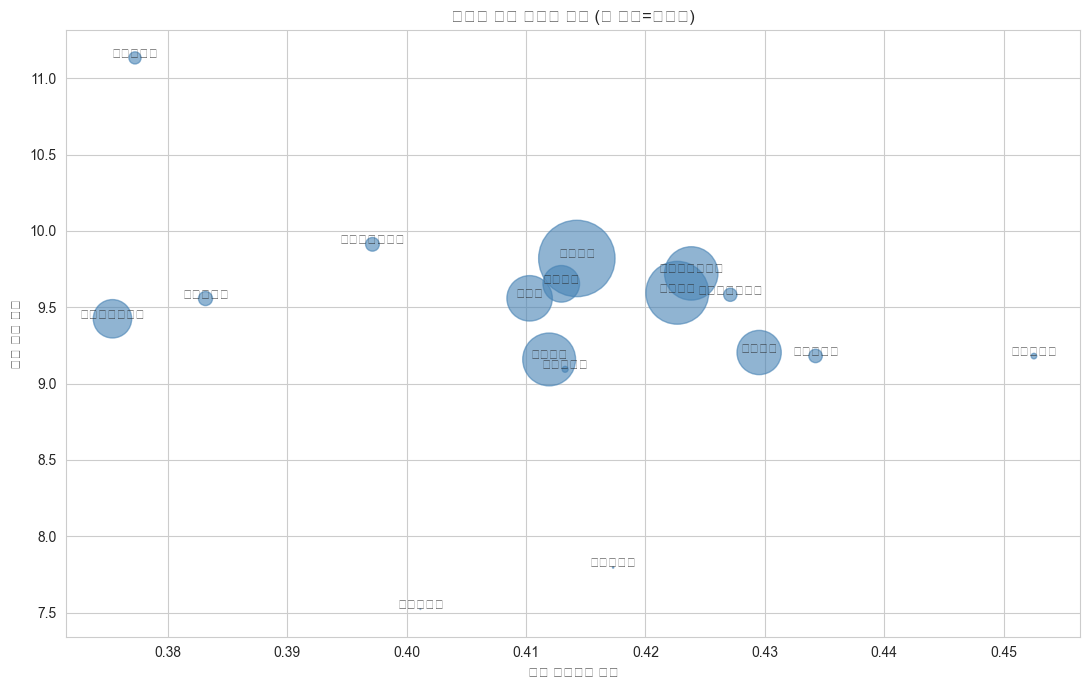

In [10]:
# 시도별 평균 고온노출 비율과 평균 등급을 계산하고, 산점도로 그리기 셀13

#sido 별로 데이터 묶어서 요약통계 계산
# mean_heat : 시도별 평균 고온노출 비율
# mean_grade : 시도별 평균 등급 점수
# n : 시도별 소 개수
sido_stats = df.groupby("sido").agg(
    mean_heat=("ratio_고온","mean"),
    mean_grade=("grade_num","mean"),
    n=("CATTLE_NO","count")
).reset_index() #그룹결과를 일반 데이터프레임 형태로 변환

#시도별 산점도 그림
# x축 : mean_heat
# y축 : mean_grade
# 점 크기 : sido_status["n"]/200 -> 점이 클수록 해당 시도의 데이터 수가 많음
plt.figure(figsize=(11, 7))
plt.scatter(sido_stats["mean_heat"], sido_stats["mean_grade"],
            s=sido_stats["n"]/200, alpha=0.6, color="steelblue")

#각 점 옆에 시도 이름 표시
for _, row in sido_stats.iterrows():
    plt.annotate(row["sido"], (row["mean_heat"], row["mean_grade"]),
                 fontsize=9, ha="center")
plt.xlabel("평균 고온노출 비율"); plt.ylabel("평균 등급 점수")
plt.title("시도별 더위 노출과 등급 (점 크기=마릿수)")
plt.tight_layout()
plt.savefig("../../../figures/weather-variables/15_sido_heat_grade(시도별 더위-등급 관계).png", dpi=100, bbox_inches="tight")
plt.show()

# 시도 단위로 보면 고온노출비율과 평균 등급사이 뚜렷한 선형관계는 보이지않음.
# 지역별 등급 차이는 더위뿐 아니라 사육규모,농장 특성, 출하구조, 성별 구성, 혈통 등 다른 요인의 영향을 함께 받은것으로 보임(더위 단독으론 지역별 등급 차이를 설명하기 어려움)

## 6. 정량 검정 — 더위 많이/적게 그룹 등급 차이

In [11]:
# 고온노출이 적은 그룹과 많은 그룹의 등급 차이를 통계검정
q25 = df["ratio_고온"].quantile(0.25)
q75 = df["ratio_고온"].quantile(0.75)
low_heat = df[df["ratio_고온"] <= q25]["grade_num"].dropna() #하위25%이하 소들 등급점수
high_heat = df[df["ratio_고온"] >= q75]["grade_num"].dropna() #상위 ;;
print(f"더위 적음(하위25%): N={len(low_heat):,}, 평균 등급={low_heat.mean():.3f}")
print(f"더위 많음(상위25%): N={len(high_heat):,}, 평균 등급={high_heat.mean():.3f}")

#맨 휘트니U 검정,두 그룹 등급 분포가 통계적으로 다른지 확인하는 비모수검정(two-sided : 그냥 다른지 검정)
u, p = mannwhitneyu(low_heat, high_heat, alternative="two-sided")
print(f"\nMann-Whitney U: p={p:.4g}")
print(f"  → {'더위 노출에 따른 등급 차이 유의' if p < 0.05 else '유의하지 않음'}")

더위 적음(하위25%): N=602,180, 평균 등급=9.313
더위 많음(상위25%): N=602,239, 평균 등급=10.568

Mann-Whitney U: p=0
  → 더위 노출에 따른 등급 차이 유의


## 7. 저장 (더위 비율 변수 추가됨)

In [12]:
df.to_csv("../../../data/processed/3_eda/step9_weather.csv",
          index=False, encoding="utf-8-sig")
print(f"저장 완료: step9_weather.csv {df.shape}")
print("추가 컬럼: ratio_고온, ratio_강더위, ratio_위험, birth_season, 고온_bin")

저장 완료: step9_weather.csv (2408699, 50)
추가 컬럼: ratio_고온, ratio_강더위, ratio_위험, birth_season, 고온_bin
